In [1]:
import pandas as pd
from pathlib import Path

folder = Path(
    r"C:\Users\prith\Restaurant-Data-Analysis\data"
)

# Find the CSV automatically
csv_files = list(folder.glob("*.csv"))

if csv_files:
    df = pd.read_csv(csv_files[0])

    df_clean = df.copy()
    df_clean["Cuisines"] = df_clean["Cuisines"].fillna("Unknown")

    display(df_clean.head())
    print("Dataset loaded:", df_clean.shape)
else:
    print("CSV file not found. Check your data folder.")

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


Dataset loaded: (9551, 21)


In [2]:
df_clean = df.copy()
df_clean["Cuisines"] = df_clean["Cuisines"].fillna("Unknown")

In [3]:

df_clean["City"].nunique()

141

In [4]:
city_counts = df_clean["City"].value_counts()

In [5]:
city_counts.head(10)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Amritsar          21
Bhubaneshwar      21
Guwahati          21
Lucknow           21
Name: count, dtype: int64

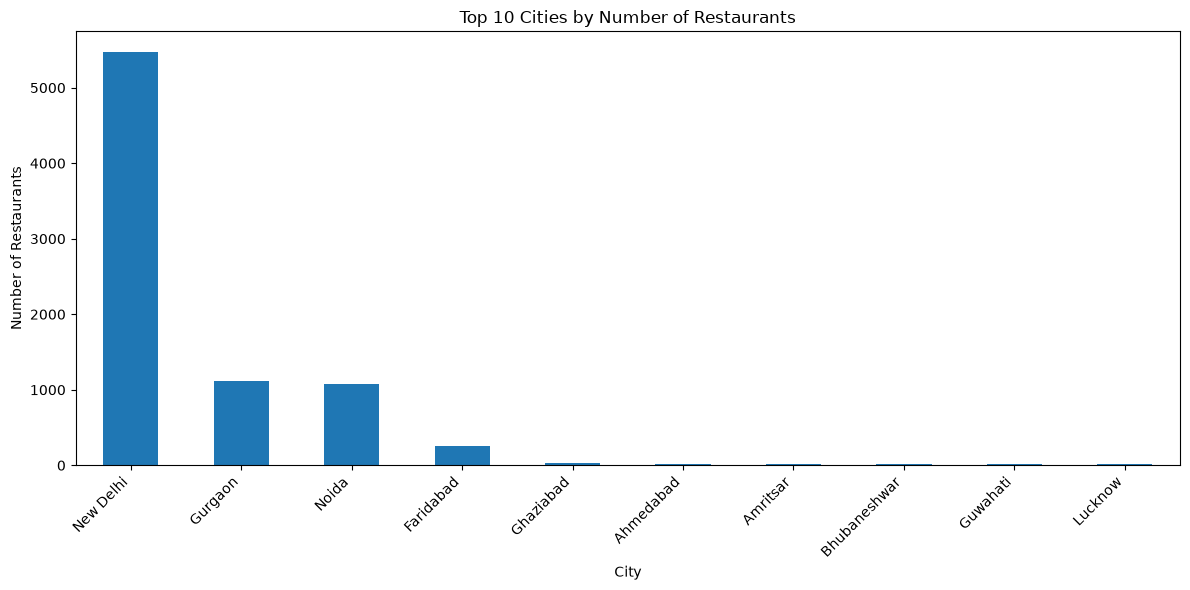

In [6]:

import matplotlib.pyplot as plt

top_10_cities = city_counts.head(10)

plt.figure(figsize=(12, 6))

top_10_cities.plot(kind="bar")

plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [7]:

total_restaurants = len(df_clean)

top_10_percentage = (
    city_counts.head(10) / total_restaurants * 100
)

top_10_percentage.round(2)

City
New Delhi       57.30
Gurgaon         11.71
Noida           11.31
Faridabad        2.63
Ghaziabad        0.26
Ahmedabad        0.22
Amritsar         0.22
Bhubaneshwar     0.22
Guwahati         0.22
Lucknow          0.22
Name: count, dtype: float64

In [8]:

print("Missing latitudes:", df_clean["Latitude"].isna().sum())
print("Missing longitudes:", df_clean["Longitude"].isna().sum())

Missing latitudes: 0
Missing longitudes: 0


In [9]:

print("Latitude range:")
print(df_clean["Latitude"].min(), df_clean["Latitude"].max())

print("\nLongitude range:")
print(df_clean["Longitude"].min(), df_clean["Longitude"].max())

Latitude range:
-41.330428 55.97698

Longitude range:
-157.948486 174.8320893


In [10]:

print("Missing latitudes:", df_clean["Latitude"].isna().sum())
print("Missing longitudes:", df_clean["Longitude"].isna().sum())

valid_coordinates = df_clean[
    df_clean["Latitude"].between(-90, 90) &
    df_clean["Longitude"].between(-180, 180)
]

print("Rows with valid coordinates:", len(valid_coordinates))
print("Total rows:", len(df_clean))

Missing latitudes: 0
Missing longitudes: 0
Rows with valid coordinates: 9551
Total rows: 9551


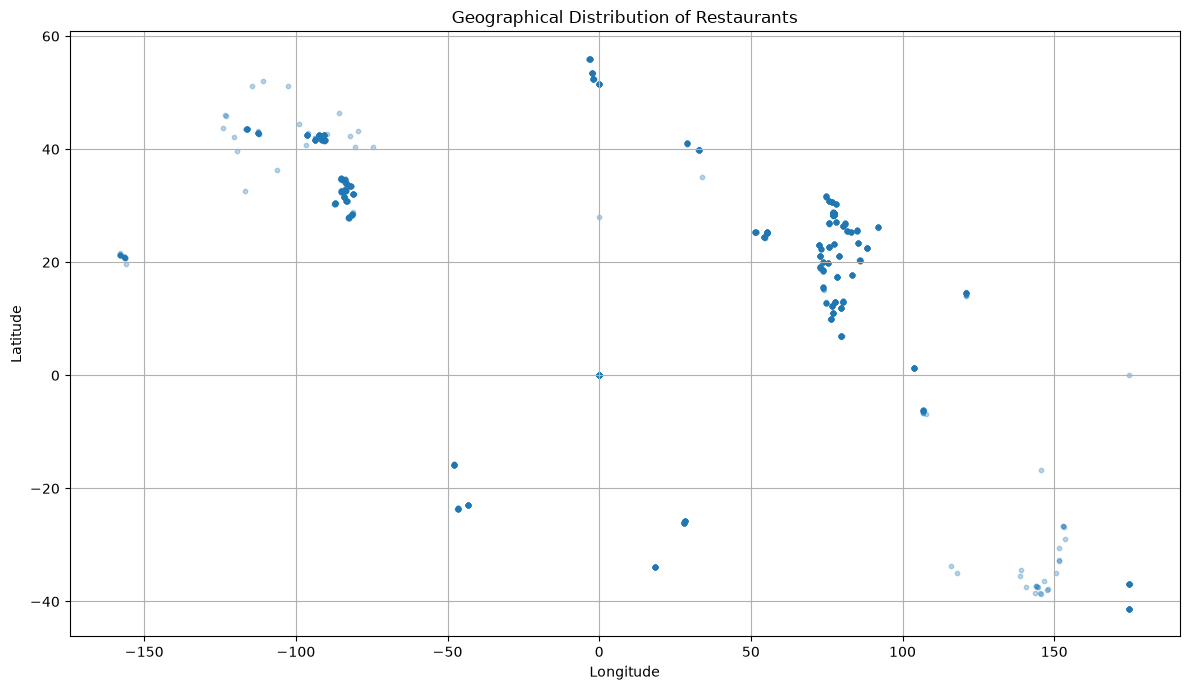

In [11]:

plt.figure(figsize=(12, 7))

plt.scatter(
    valid_coordinates["Longitude"],
    valid_coordinates["Latitude"],
    alpha=0.3,
    s=10
)

plt.title("Geographical Distribution of Restaurants")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)

plt.tight_layout()
plt.show()

In [12]:

india_df = df_clean[df_clean["Country Code"] == 1].copy()

print("Restaurants in India:", len(india_df))
print("Cities in India:", india_df["City"].nunique())

Restaurants in India: 8652
Cities in India: 43


In [13]:

india_city_counts = india_df["City"].value_counts()

india_city_counts.head(10)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Amritsar          21
Bhubaneshwar      21
Guwahati          21
Lucknow           21
Name: count, dtype: int64

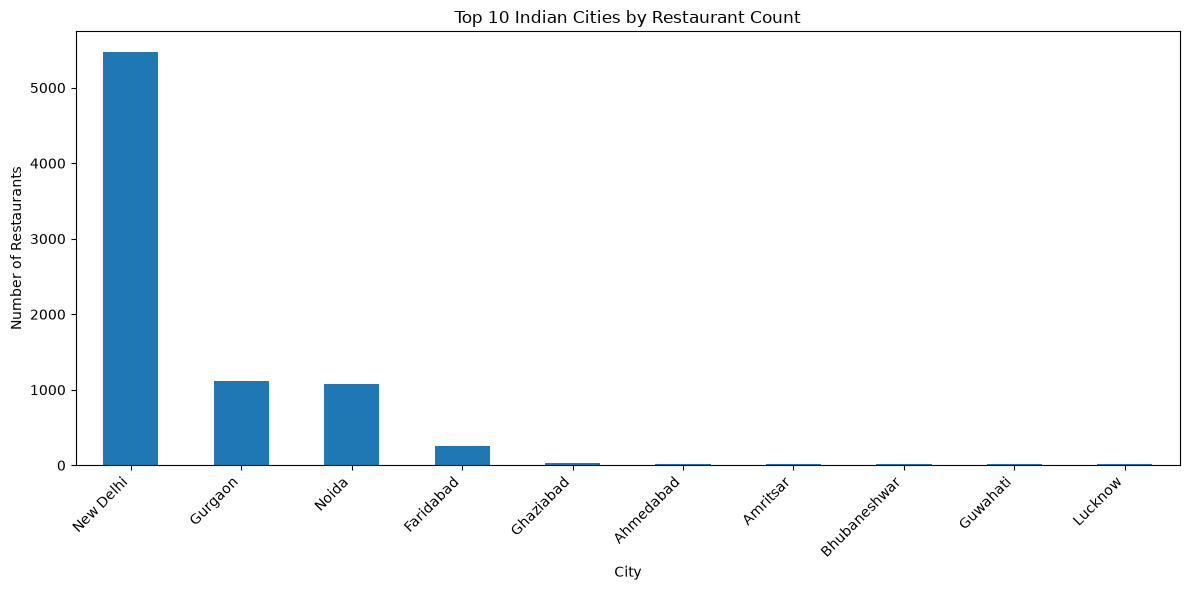

In [14]:

top_india_cities = india_city_counts.head(10)

plt.figure(figsize=(12, 6))

top_india_cities.plot(kind="bar")

plt.title("Top 10 Indian Cities by Restaurant Count")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [15]:

india_total = len(india_df)

india_city_percentage = (
    india_city_counts.head(10) / india_total * 100
)

india_city_percentage.round(2)

City
New Delhi       63.26
Gurgaon         12.92
Noida           12.48
Faridabad        2.90
Ghaziabad        0.29
Ahmedabad        0.24
Amritsar         0.24
Bhubaneshwar     0.24
Guwahati         0.24
Lucknow          0.24
Name: count, dtype: float64

In [16]:

rated_india_df = india_df[
    india_df["Aggregate rating"] > 0
].copy()

city_rating = (
    rated_india_df
    .groupby("City")["Aggregate rating"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

city_rating.head(10).round(2)

,mean,count
City,,
Secunderabad,4.50,2
Bangalore,4.38,20
Hyderabad,4.34,18
Chennai,4.31,20
Mohali,4.30,1
Kolkata,4.26,20
Goa,4.24,20
Pune,4.22,20
Panchkula,4.20,1


In [17]:

reliable_city_rating = city_rating[
    city_rating["count"] >= 30
].sort_values("mean", ascending=False)

print("Cities with at least 30 rated restaurants:",
      len(reliable_city_rating))

reliable_city_rating.head(10).round(2)

Cities with at least 30 rated restaurants: 4


,mean,count
City,,
Gurgaon,3.33,890
New Delhi,3.30,4048
Noida,3.16,696
Faridabad,3.10,151


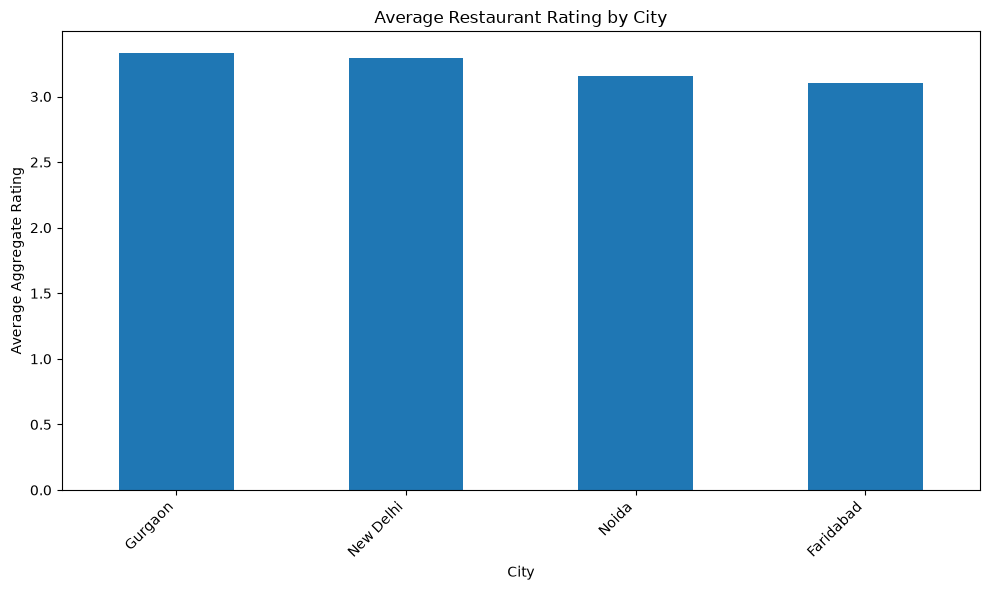

In [18]:

plt.figure(figsize=(10, 6))

reliable_city_rating["mean"].plot(kind="bar")

plt.title("Average Restaurant Rating by City")
plt.xlabel("City")
plt.ylabel("Average Aggregate Rating")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

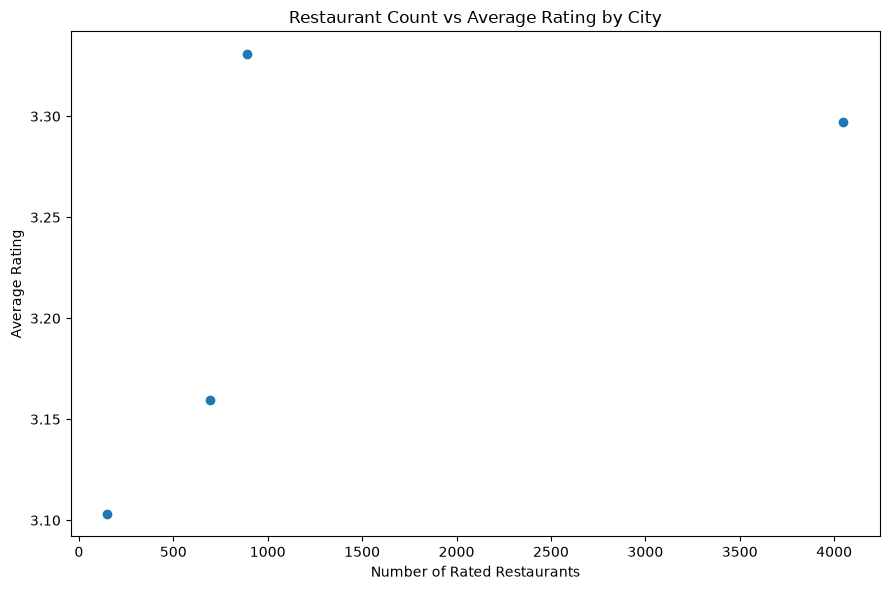

In [19]:

plt.figure(figsize=(9, 6))

plt.scatter(
    reliable_city_rating["count"],
    reliable_city_rating["mean"]
)

plt.title("Restaurant Count vs Average Rating by City")
plt.xlabel("Number of Rated Restaurants")
plt.ylabel("Average Rating")

plt.tight_layout()
plt.show()

In [20]:

india_geo = india_df[
    india_df["Latitude"].between(-90, 90) &
    india_df["Longitude"].between(-180, 180) &
    india_df["Latitude"].notna() &
    india_df["Longitude"].notna()
].copy()

print("Indian records with valid coordinates:", len(india_geo))

Indian records with valid coordinates: 8652


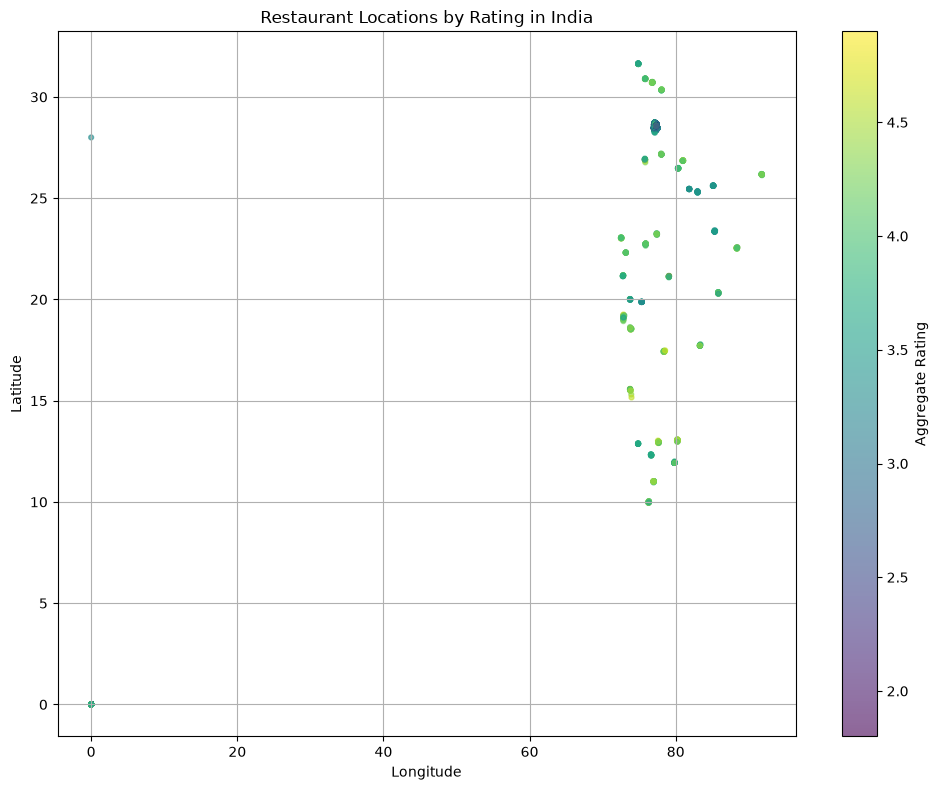

In [21]:

india_rated_geo = india_geo[
    india_geo["Aggregate rating"] > 0
].copy()

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    india_rated_geo["Longitude"],
    india_rated_geo["Latitude"],
    c=india_rated_geo["Aggregate rating"],
    alpha=0.6,
    s=12
)

plt.colorbar(scatter, label="Aggregate Rating")
plt.title("Restaurant Locations by Rating in India")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)

plt.tight_layout()
plt.show()

In [22]:

print("Total Indian restaurant records:", len(india_df))
print("Unique Indian cities:", india_df["City"].nunique())

india_rated = india_df[
    india_df["Aggregate rating"] > 0
]

print("Rated Indian restaurants:", len(india_rated))
print(
    "Average rating in India:",
    round(india_rated["Aggregate rating"].mean(), 2)
)

Total Indian restaurant records: 8652
Unique Indian cities: 43
Rated Indian restaurants: 6513
Average rating in India: 3.35
